In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('Salary_Data.csv')

In [51]:
df.shape

(30, 3)

In [52]:
df.head()

,YearsExperience,Age,Salary
0,1.1,21.0,39343
1,1.3,21.5,46205
2,1.5,21.7,37731
3,2.0,22.0,43525
4,2.2,22.2,39891


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Age              30 non-null     float64
 2   Salary           30 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [54]:
df.isnull().sum()

YearsExperience    0
Age                0
Salary             0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
from sklearn.model_selection import train_test_split
x_train , x_test,y_train,y_test = train_test_split(df.drop('YearsExperience',axis=1),df['YearsExperience'],test_size=0.2,random_state=42)

x_train.shape,x_test.shape

((24, 2), (6, 2))

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# fit the scaler to the training data it will learn parameters from the training set
scaler.fit(x_train)

#transform the training and testing data
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [58]:
scaler.mean_ 

array([2.70666667e+01, 7.42076250e+04])

In [59]:
x_train

,Age,Salary
28,37.0,122391
24,33.0,109431
12,24.0,56957
0,21.0,39343
4,22.2,39891
16,26.0,66029
5,23.0,56642
13,24.0,57081
11,24.0,55794
22,31.0,101302


In [60]:
x_train_scaled

array([[ 1.92572931,  1.74286179],
       [ 1.15026784,  1.27408   ],
       [-0.59452046, -0.62397985],
       [-1.17611656, -1.26110349],
       [-0.94347812, -1.24128155],
       [-0.20678972, -0.2958326 ],
       [-0.78838583, -0.63537385],
       [-0.59452046, -0.61949459],
       [-0.59452046, -0.66604723],
       [ 0.76253711,  0.98004241],
       [-1.07918388, -1.01289511],
       [-1.0404108 , -1.31941185],
       [ 1.34413321,  1.13485615],
       [-0.98225119, -1.10983456],
       [ 0.56867174,  0.87047913],
       [ 1.53799858,  1.54674027],
       [ 0.18094101,  0.25882018],
       [ 2.11959468,  1.72408881],
       [ 0.56867174,  0.63409881],
       [-0.73022622, -0.71484249],
       [-0.613907  , -0.3975105 ],
       [-0.40065509, -0.47372371],
       [ 0.37480638,  0.71374831],
       [-0.78838583, -0.50848446]])

In [61]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [62]:
x_train_scaled

,Age,Salary
0,1.925729,1.742862
1,1.150268,1.274080
2,-0.594520,-0.623980
3,-1.176117,-1.261103
4,-0.943478,-1.241282
5,-0.206790,-0.295833
6,-0.788386,-0.635374
7,-0.594520,-0.619495
8,-0.594520,-0.666047
9,0.762537,0.980042


In [63]:
x_test_scaled

,Age,Salary
0,1.731864,1.389973
1,-0.400655,-0.226781
2,0.956402,1.432547
3,-0.012924,0.321216
4,-0.730226,-0.353128
5,-0.672067,-0.615588


In [64]:
np.round(x_test_scaled.describe(), 1)

,Age,Salary
count,6.0,6.0
mean,0.1,0.3
std,1.0,0.9
min,-0.7,-0.6
25%,-0.6,-0.3
50%,-0.2,0.0
75%,0.7,1.1
max,1.7,1.4


In [65]:
np.round(x_train_scaled.describe(), 1)

,Age,Salary
count,24.0,24.0
mean,0.0,0.0
std,1.0,1.0
min,-1.2,-1.3
25%,-0.8,-0.7
50%,-0.5,-0.4
75%,0.6,0.9
max,2.1,1.7


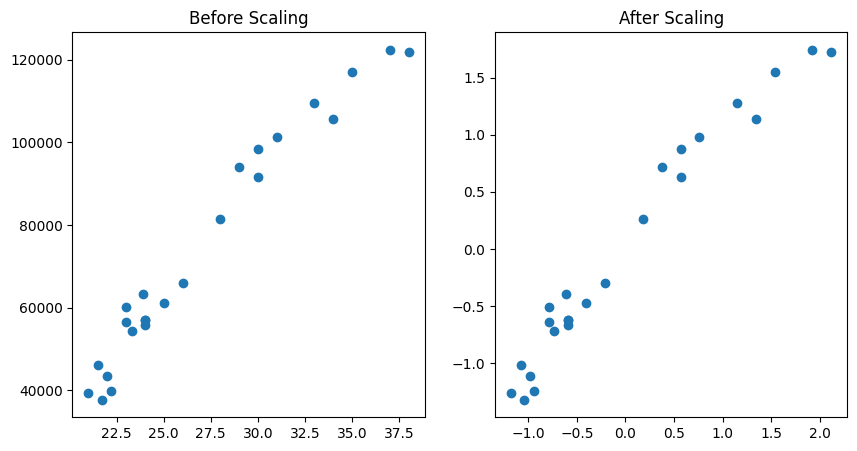

In [66]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(10,5))

#before scaling
ax1.scatter(x_train['Age'],x_train['Salary'])
ax1.set_title('Before Scaling')

#after scaling
ax2.scatter(x_train_scaled['Age'],x_train_scaled['Salary'])
ax2.set_title('After Scaling')
plt.show()

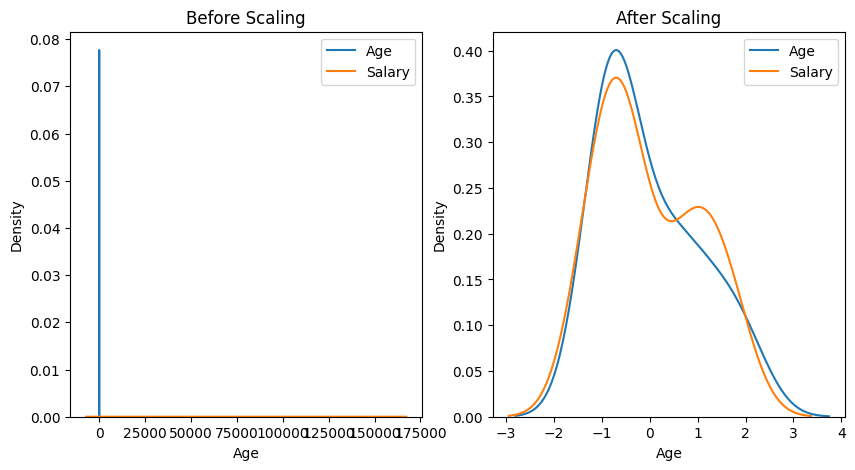

In [67]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,5))

# Before Scaling
ax1.set_title('Before Scaling')

sns.kdeplot(x_train['Age'], ax=ax1, label='Age')
sns.kdeplot(x_train['Salary'], ax=ax1, label='Salary')

ax1.legend()

# After Scaling
ax2.set_title('After Scaling')

sns.kdeplot(x_train_scaled['Age'], ax=ax2, label='Age')
sns.kdeplot(x_train_scaled['Salary'], ax=ax2, label='Salary')

ax2.legend()

plt.show()

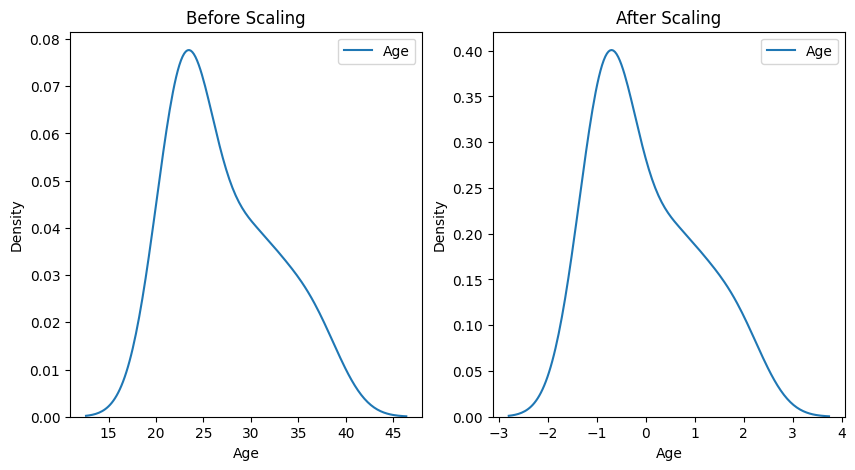

In [68]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,5))

# Before Scaling
ax1.set_title('Before Scaling')

sns.kdeplot(x_train['Age'], ax=ax1, label='Age')


ax1.legend()

# After Scaling
ax2.set_title('After Scaling')

sns.kdeplot(x_train_scaled['Age'], ax=ax2, label='Age')


ax2.legend()

plt.show()

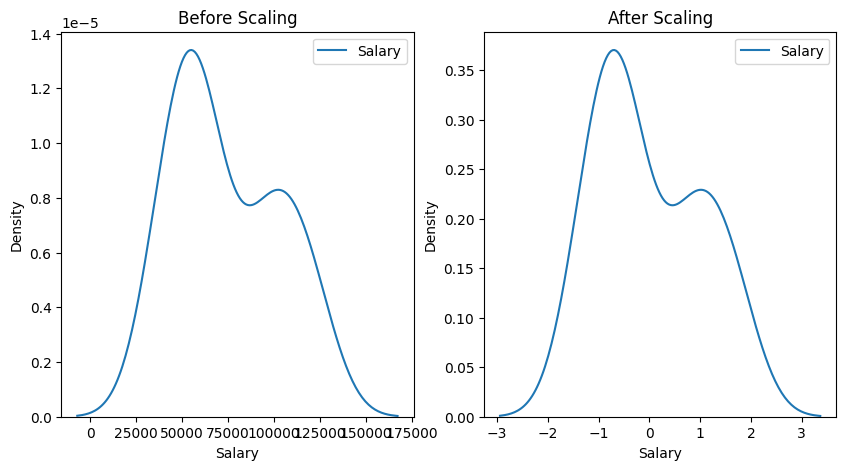

In [69]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,5))

# Before Scaling
ax1.set_title('Before Scaling')


sns.kdeplot(x_train['Salary'], ax=ax1, label='Salary')

ax1.legend()

# After Scaling
ax2.set_title('After Scaling')


sns.kdeplot(x_train_scaled['Salary'], ax=ax2, label='Salary')

ax2.legend()

plt.show()

In [70]:
from sklearn.linear_model import LinearRegression

In [71]:
lr = LinearRegression()
lr_scaled = LinearRegression()


In [72]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [73]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [74]:
from sklearn.metrics import r2_score
print("Actual : ", r2_score(y_test, y_pred))
print("Scaled : ", r2_score(y_test, y_pred_scaled))

Actual :  0.9751554170304263
Scaled :  0.9751554170304263


In [75]:
from sklearn.neighbors import KNeighborsRegressor

In [76]:
knn = KNeighborsRegressor(n_neighbors=3)

knn_scaled = KNeighborsRegressor(n_neighbors=3)

In [77]:
knn.fit(x_train, y_train)

knn_scaled.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [78]:
y_pred = knn.predict(x_test)

y_pred_scaled = knn_scaled.predict(x_test_scaled)

In [79]:
from sklearn.metrics import r2_score

print("Before Scaling:",
      r2_score(y_test, y_pred))

print("After Scaling:",
      r2_score(y_test, y_pred_scaled))

Before Scaling: 0.8496856315636189
After Scaling: 0.9839303763855339
